# Figure 1AB, Figure 2, and Table 1

This notebook renders the saved 30-split model-comparison results. Every point
model is fitted on the registered training subset, split-conformal residuals are
calibrated on validation, and the test subset is used once for final reporting.

The rendering code is kept inline so that Figures 1 and 2 and the Table 1
fragment are generated entirely from this notebook. The only shared dependency
is `results/tables/model_comparison_summary.csv`, which is written by
`scripts/train_model_splits.py`.

In [1]:
from pathlib import Path
import itertools
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SUMMARY = ROOT / "results" / "tables" / "model_comparison_summary.csv"
if not SUMMARY.is_file():
    raise FileNotFoundError("Run scripts/train_model_splits.py before rendering the figures.")

In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

STYLE = {
    "Baseline": ("#2c7f8f", "///"),
    "PCA": ("#a7a85a", "..."),
    "ADME": ("#4f6fa2", "\\\\"),
    "Plain": ("#c96449", "xx"),
    "BBB pass": ("#7f7f7f", "++"),
}
LEGEND = {
    "Baseline": "Baseline:  MW+logP+FP+Energies (44 proteins)",
    "PCA": "PCA:         MW+logP+FP+Energies (PC1+PC2+PC3)",
    "ADME": "ADME:      MW+logP+FP+Energies (44 proteins) + ADMETLab3.0",
    "Plain": "Plain:        MW+logP+FP",
    "BBB pass": "BBB pass: Baseline (trained and tested only on BBB-permeant compounds)",
}
PANEL_A = ["Baseline", "PCA", "ADME", "Plain"]
PANEL_B = ["Plain", "BBB pass"]


def select(summary, model, domain):
    rows = summary.loc[summary["model"].eq(model) & summary["evaluation_domain"].eq(domain)]
    if len(rows) != 1:
        raise ValueError(f"Expected one summary row for {model}/{domain}; got {len(rows)}")
    return rows.iloc[0]


def subtitle(rows):
    mean_n = np.mean([row["n_test_mean"] for row in rows])
    min_n = min(int(row["n_test_min"]) for row in rows)
    max_n = max(int(row["n_test_max"]) for row in rows)
    return f"Same held-out set within each split: n = {mean_n:.0f} ({min_n:,}-{max_n:,})"


def draw_panel(ax, title, rows, models, metrics, labels):
    positions = np.arange(len(metrics))

    width = 0.15 if len(models) == 4 else 0.24
    offsets = (np.arange(len(models)) - (len(models) - 1) / 2) * width
    for offset, row, model in zip(offsets, rows, models):
        color, hatch = STYLE[model]
        means = [row[f"{metric}_mean"] for metric in metrics]
        errors = [row[f"{metric}_std"] for metric in metrics]
        ax.bar(
            positions + offset,
            means,
            width=width * 0.88,
            yerr=errors,
            color=color,
            hatch=hatch,
            edgecolor="white",
            linewidth=0.8,
            error_kw={"ecolor": "#22262b", "elinewidth": 1.0, "capsize": 2.8, "capthick": 1.0},
            zorder=3,
        )
    ax.set_title(title, loc="left", fontsize=13.5, fontweight="bold", pad=28)
    ax.text(0, 1.025, subtitle(rows), transform=ax.transAxes, fontsize=9.4, color="#4d5560")
    ax.set_xticks(positions, labels, fontsize=12)
    ax.tick_params(axis="y", labelsize=12, length=0)
    ax.grid(axis="y", color="#e7e4de", linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#d6d6d2")
    ax.set_facecolor("#fbfaf7")


def add_legend(ax, models, labels):
    ax.legend(
        [Patch(facecolor=STYLE[model][0], edgecolor="white", hatch=STYLE[model][1]) for model in models],
        labels,
        loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
        frameon=True,
        facecolor="white",
        edgecolor="#e8e4dc",
        fontsize=8.2,
        labelspacing=0.38,
        handlelength=2.0,
        borderpad=0.30,
    )


def base_figure():
    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "hatch.linewidth": 1.4})
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 7.4), sharey=True)
    fig.set_facecolor("white")
    fig.subplots_adjust(left=0.07, right=0.995, bottom=0.12, top=0.95, wspace=0.035)
    return fig, axes


def write_copies(source, official):
    for path in official:
        path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source, path)

In [3]:
summary = pd.read_csv(SUMMARY)

METRICS_FIG1 = ["RMSE", "MAE", "MSE", "R2", "Spearman", "CCC"]
LABELS_FIG1 = ["RMSE", "MAE", "MSE", "$R^2$", "Spearman", "CCC"]
rows_a = [select(summary, model, "full_test") for model in PANEL_A]
rows_b = [select(summary, model, "bbb_pass_test") for model in PANEL_B]

fig, axes = base_figure()
draw_panel(axes[0], "A. Full chemical domain", rows_a, PANEL_A, METRICS_FIG1, LABELS_FIG1)
draw_panel(axes[1], "B. BBB-permeant molecules only", rows_b, PANEL_B, METRICS_FIG1, LABELS_FIG1)
axes[0].set_ylabel("Metric value", fontsize=13)
add_legend(axes[0], PANEL_A, [LEGEND[m] for m in PANEL_A])
add_legend(axes[1], PANEL_B, ["Plain (trained on full dataset; test: BBB-permeant compounds only)", LEGEND["BBB pass"]])
fig.text(0.5, 0.035, "Bars: mean across 30 splits. Error bars: sample standard deviation across splits.", ha="center", fontsize=10, color="#4d5560")

fig1 = ROOT / "results" / "figures" / "manuscript" / "fig1.png"
fig1.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig1, dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight", pad_inches=0.03)
plt.close(fig)
write_copies(fig1, [
    ROOT / "results" / "figures" / "metrics" / "performance_comparison.png",
    ROOT / "manuscript" / "fig1.png",
])
print(f"Saved: {fig1.relative_to(ROOT)}")

Saved: results/figures/manuscript/fig1.png


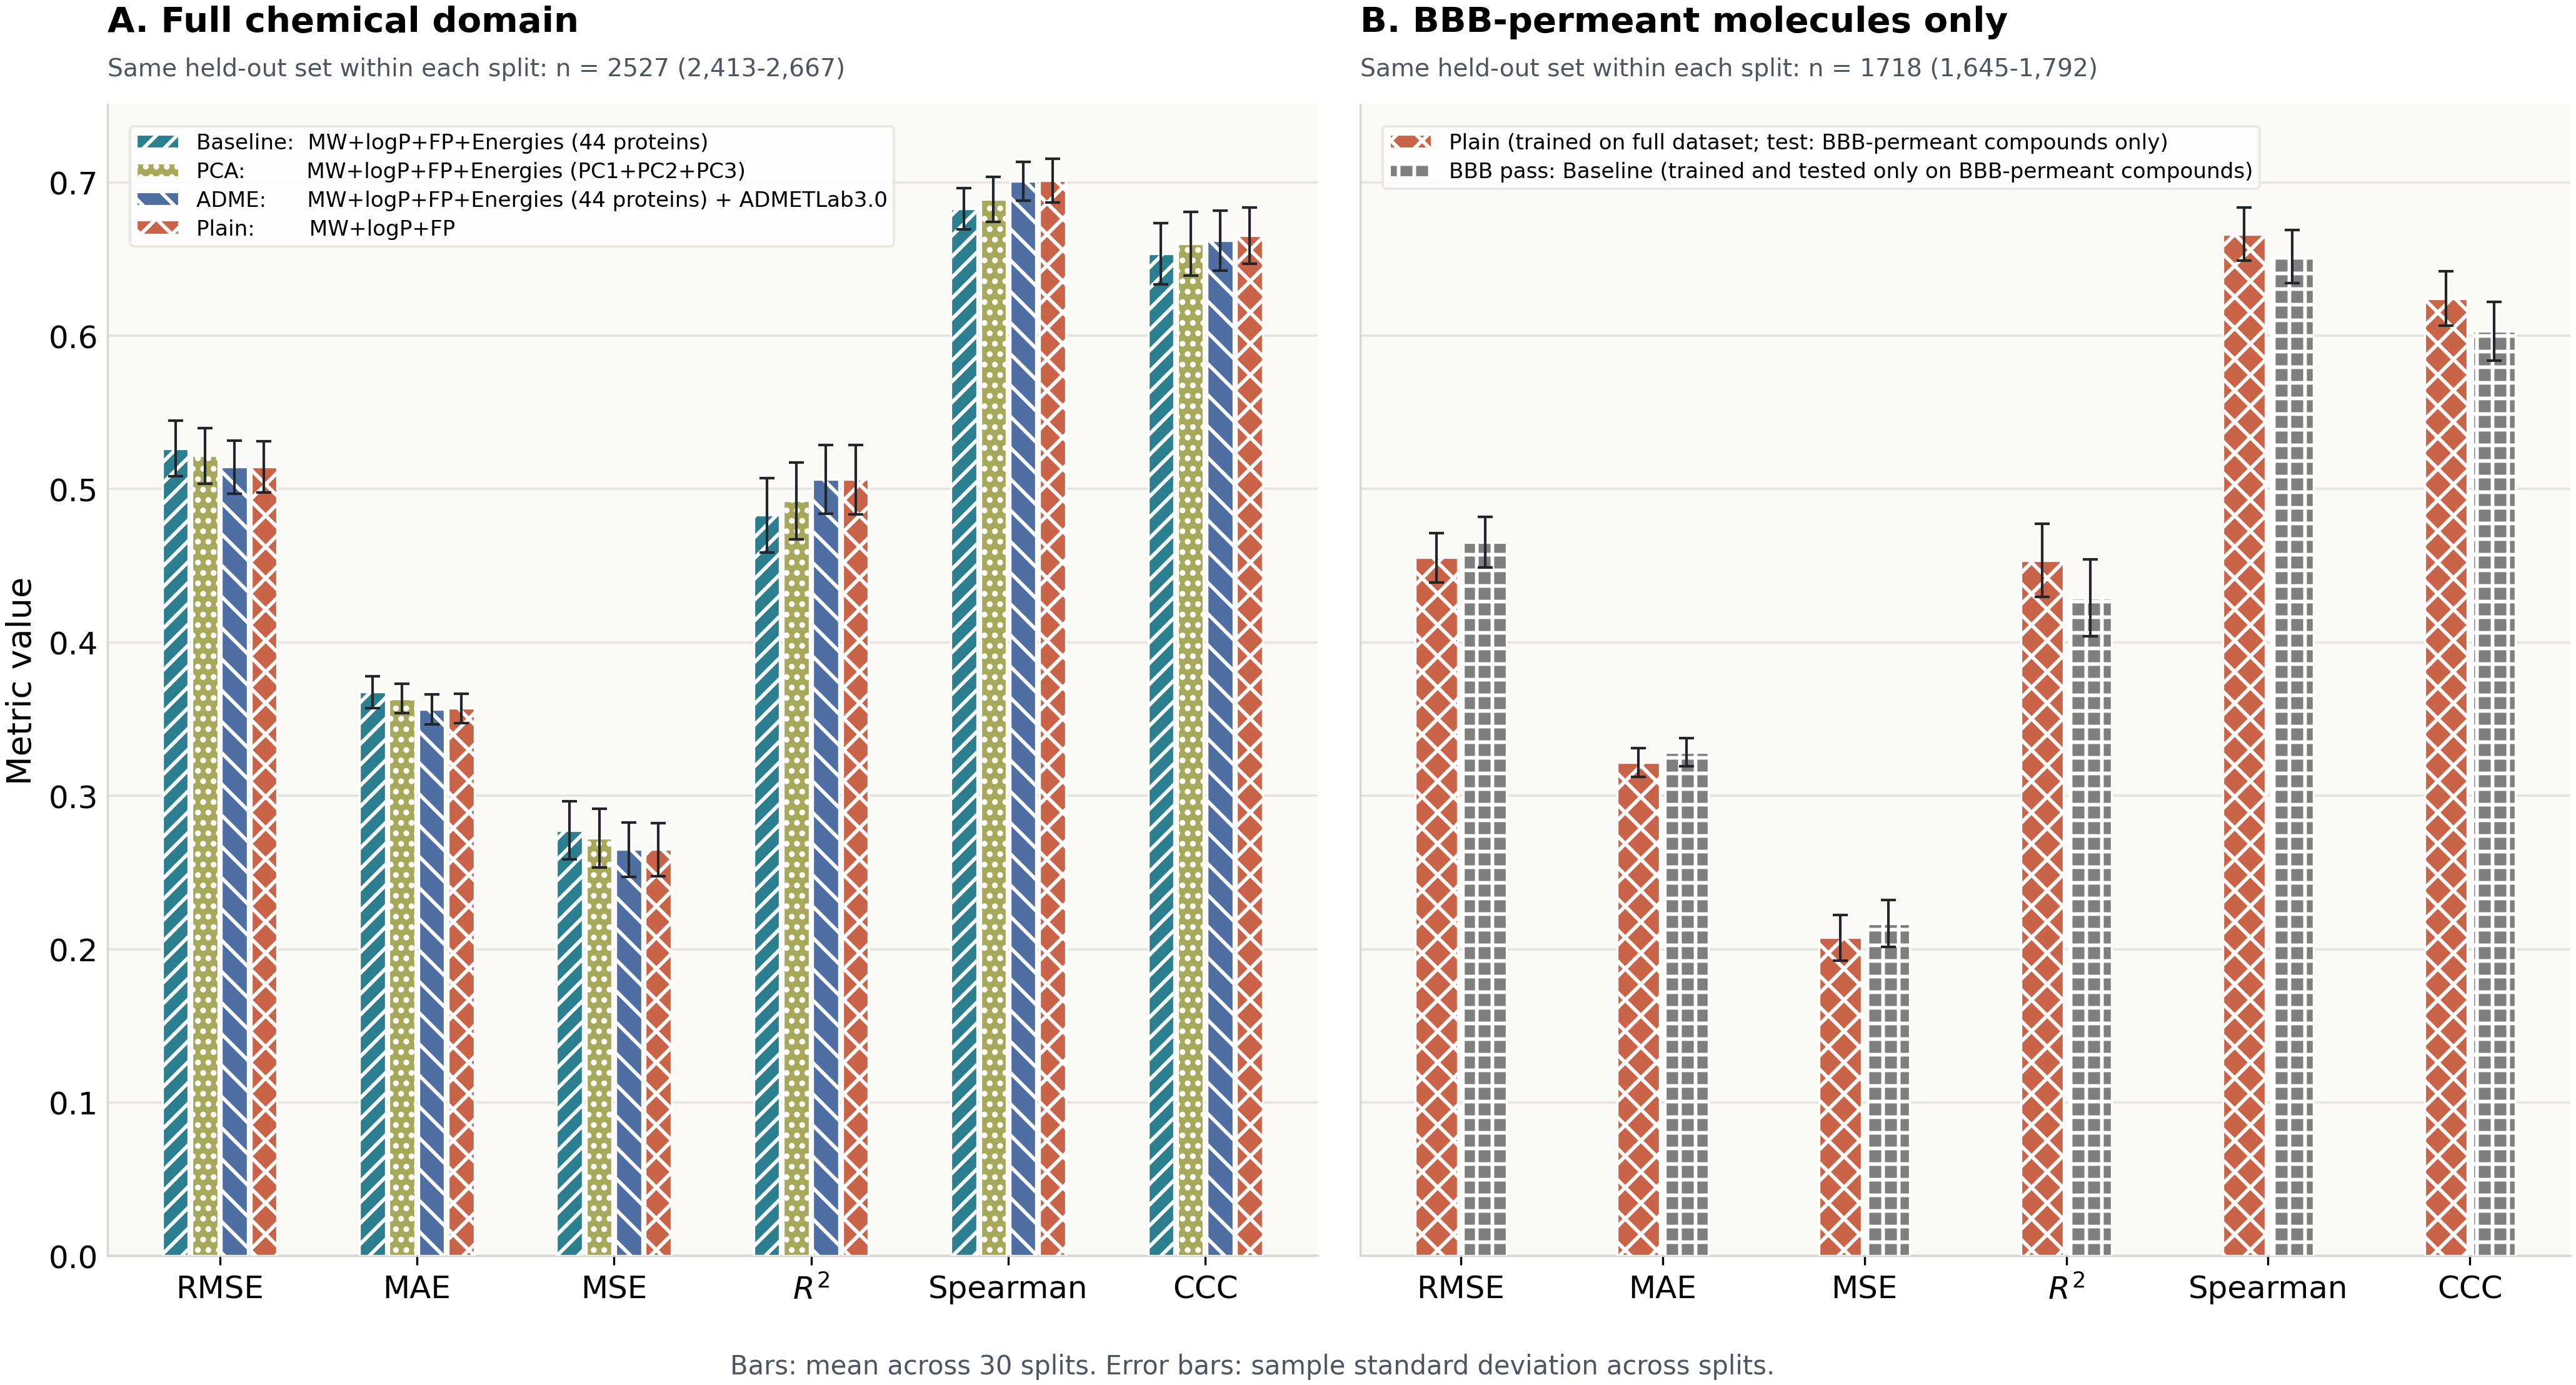

In [4]:
from IPython.display import Image, display

display(Image(filename=str(fig1)))

In [5]:
summary = pd.read_csv(SUMMARY)

METRICS_FIG2 = ["CI_0.80_size", "CI_0.90_size", "CI_0.95_size"]
LABELS_FIG2 = ["80% PI", "90% PI", "95% PI"]
rows_a = [select(summary, model, "full_test") for model in PANEL_A]
rows_b = [select(summary, model, "bbb_pass_test") for model in PANEL_B]

fig, axes = base_figure()
draw_panel(axes[0], "A. Full chemical domain", rows_a, PANEL_A, METRICS_FIG2, LABELS_FIG2)
draw_panel(axes[1], "B. BBB-permeant molecules only", rows_b, PANEL_B, METRICS_FIG2, LABELS_FIG2)
axes[0].set_ylabel("Prediction interval length", fontsize=13)
add_legend(axes[0], PANEL_A, [LEGEND[m] for m in PANEL_A])
add_legend(axes[1], PANEL_B, ["Plain (trained on full dataset; test: BBB-permeant compounds only)", LEGEND["BBB pass"]])
fig.text(0.5, 0.035, "Bars: mean interval length across 30 splits. Error bars: sample standard deviation across splits.", ha="center", fontsize=10, color="#4d5560")

fig2 = ROOT / "results" / "figures" / "manuscript" / "fig2.png"
fig2.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig2, dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight", pad_inches=0.03)
plt.close(fig)
write_copies(fig2, [
    ROOT / "results" / "figures" / "metrics" / "conformal_intervals.png",
    ROOT / "manuscript" / "fig2.png",
])
print(f"Saved: {fig2.relative_to(ROOT)}")

Saved: results/figures/manuscript/fig2.png


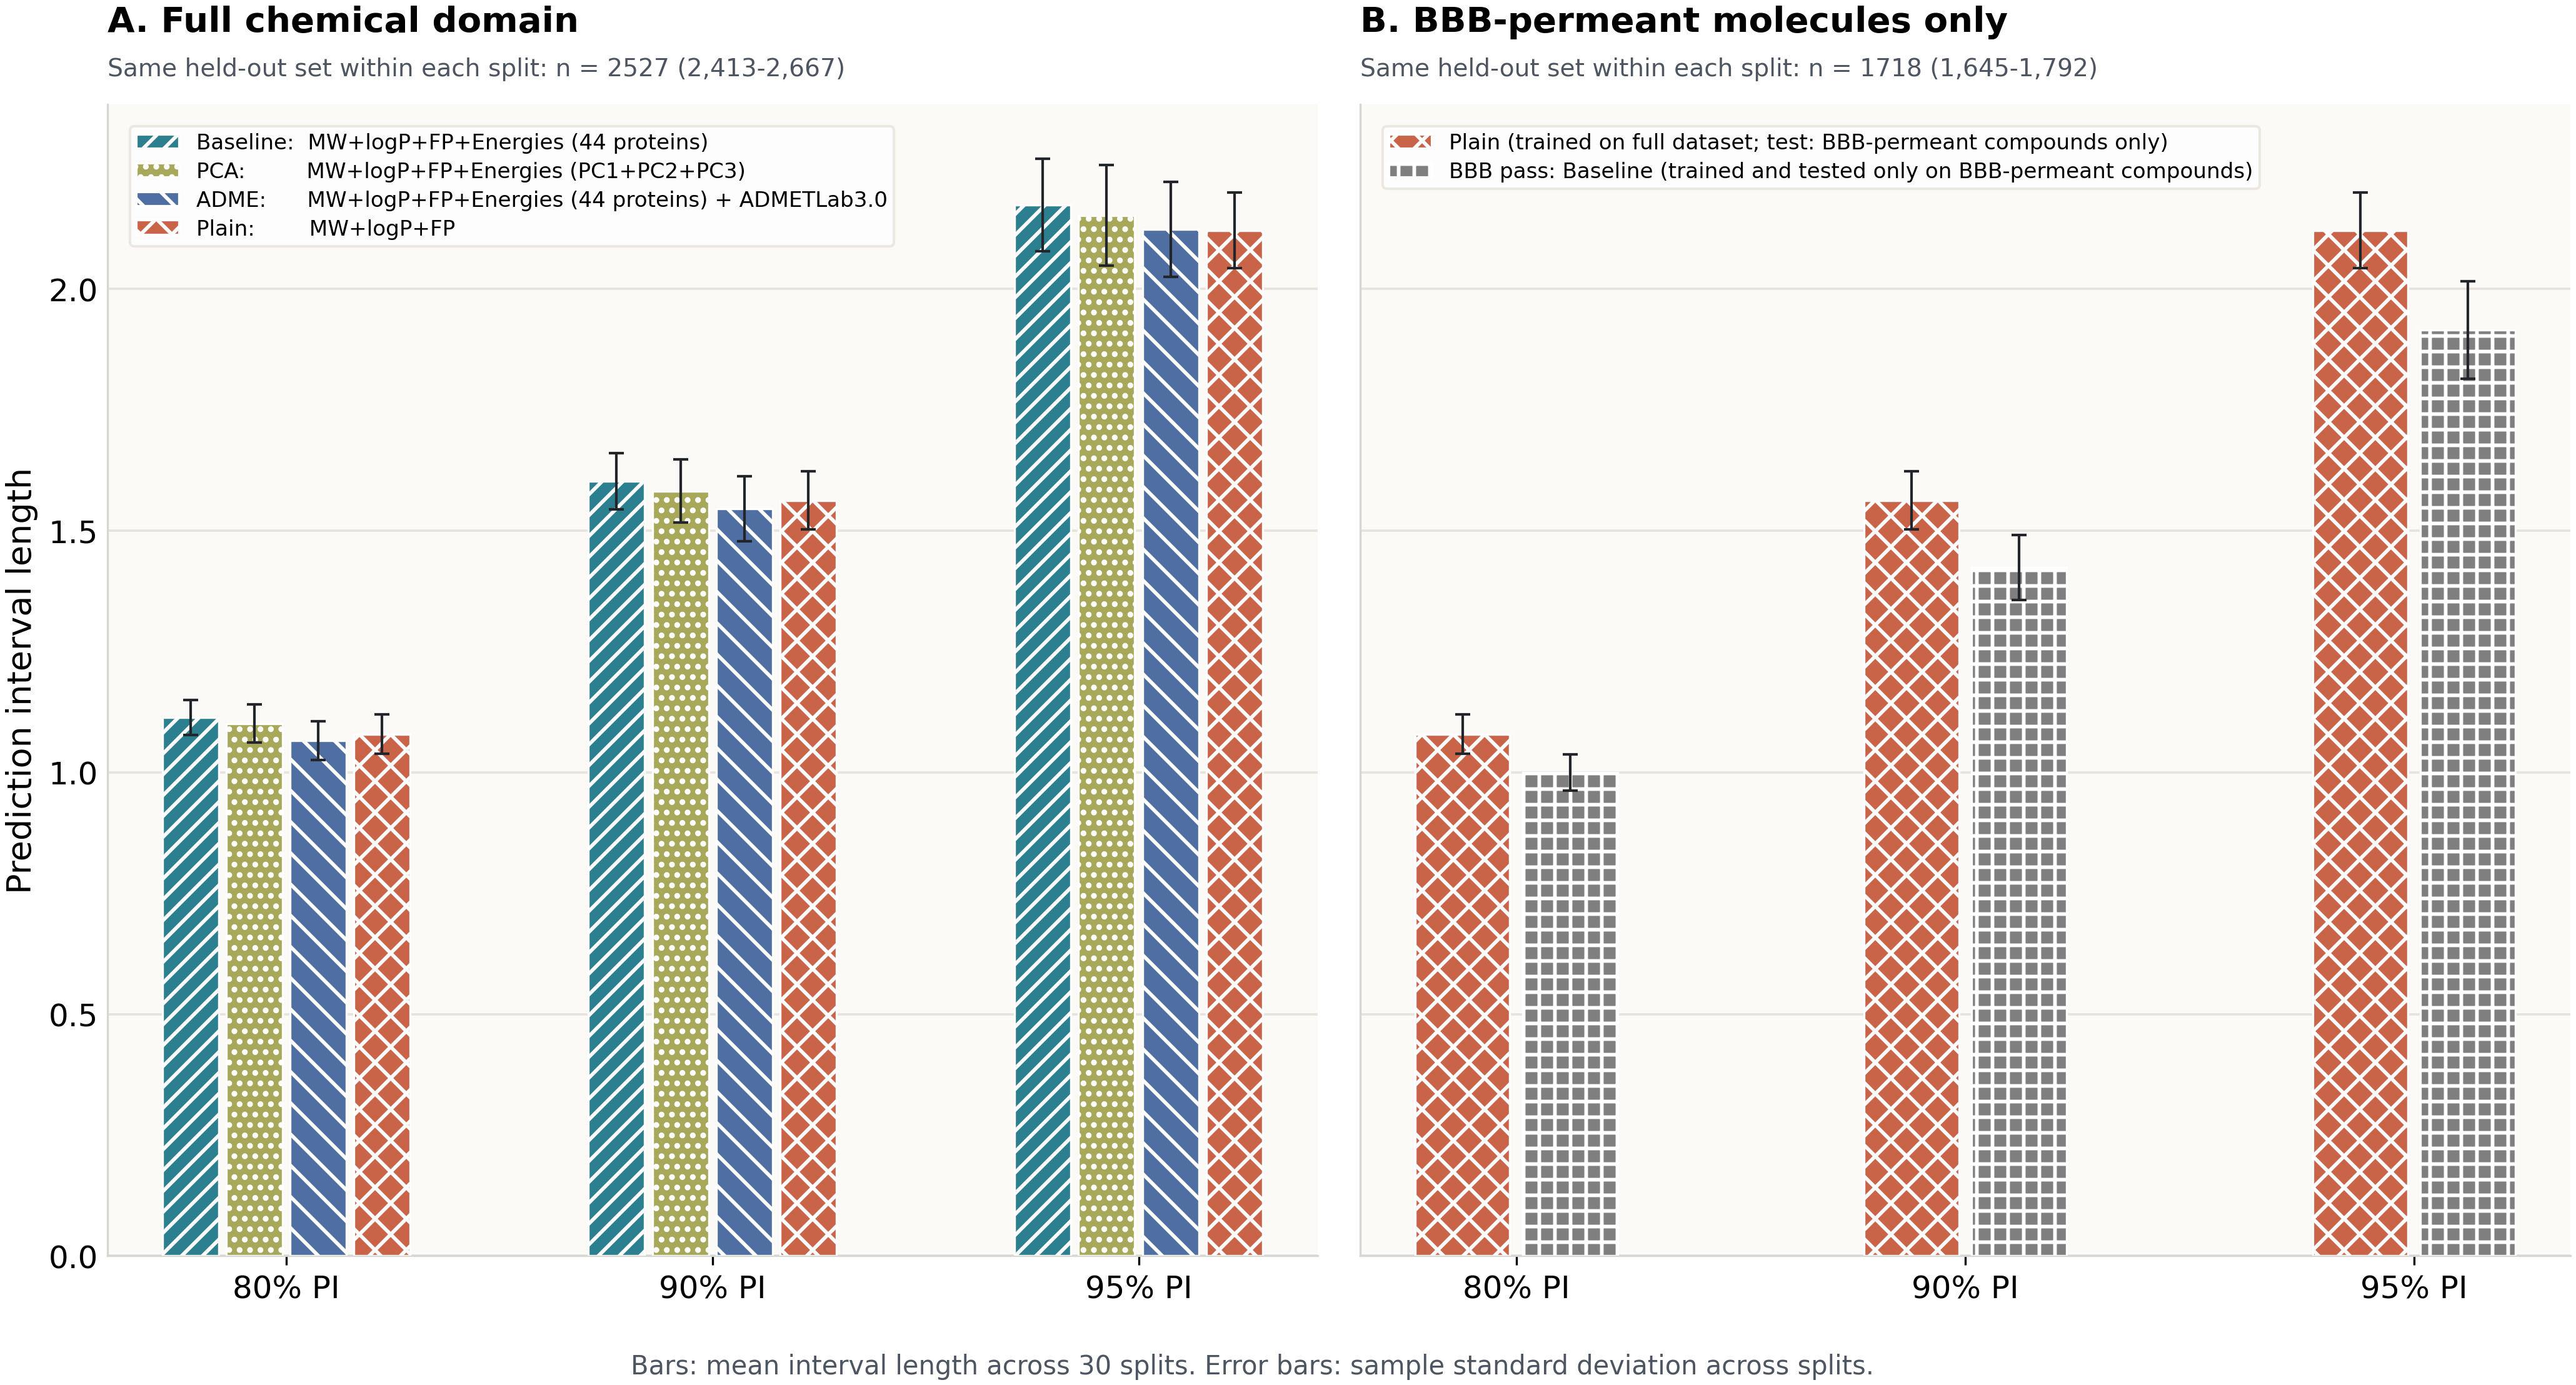

In [6]:
display(Image(filename=str(fig2)))

In [7]:
table = subprocess.run(
    [sys.executable, str(ROOT / "scripts" / "build_model_comparison_table.py")],
    check=True,
    capture_output=True,
    text=True,
)
print(table.stdout.strip())

Wrote: /home/safronov/code/opencode/tox/reporev2j/manuscript/tables/table1_model_quality.tex
